# Expected swings and downside risk

Two questions, answered one after the other because the second uses the first.

1. **How large are the price swings likely to be next?** (volatility forecast)
2. **How much could be lost in a bad period, and how often has that limit been
   broken?** (Value at Risk and expected shortfall)

Everything shown is "walk-forward": each forecast was made from data up to its own day
by a model fitted on earlier days, then compared with what happened.

Rebuild with `uv run python backend/scripts/build_notebooks.py 04_volatility_and_risk`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sqlalchemy import select

from radar.db.models import RiskMetric, VolatilityForecast
from radar.db.session import make_engine, session_scope
from radar.models import tail_risk, volatility
from radar.pipelines import risk as risk_job
from radar.pipelines import volatility as volatility_job
from radar.pipelines.datasets import build_regime_observations
from radar.universe import get_universe

plt.rcParams.update({"figure.figsize": (11, 3.4), "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
engine, universe = make_engine(), get_universe()
symbols = [a.symbol for a in universe.primary]
NAMES = {"har": "HAR regression", "gbt": "Tree model", "carry": "Yesterday repeated", "regime": "Regime average"}

with session_scope(engine) as session:
    forecasts = pd.read_sql(select(VolatilityForecast), session.connection())
    risk = pd.read_sql(select(RiskMetric), session.connection())
    vol_metrics = {s: volatility_job.current_model(session, s).metrics["horizons"] for s in symbols}
    vol_params = {s: volatility_job.current_model(session, s).params for s in symbols}
    risk_metrics = {s: risk_job.current_model(session, s).metrics for s in symbols}
    btc = build_regime_observations(session, universe.get("BTC/USD"))

## Part 1. The volatility forecast

### The idea behind HAR

Tomorrow's swings look like a blend of three things: how rough **yesterday** was, how
rough the **last week** was, and how rough the **last month** was. HAR is a plain
regression on those three numbers. It is simple and famously hard to beat.

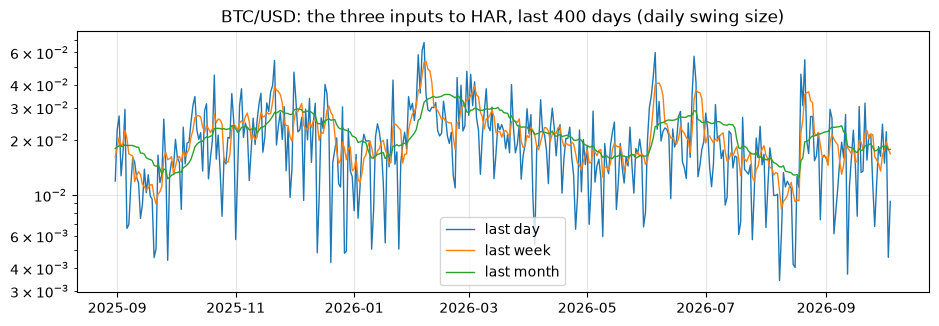

In [2]:
features = volatility.har_features(btc["rv"]).dropna()
fig, ax = plt.subplots()
recent = features.iloc[-400:]
for column, label in (("log_day", "last day"), ("log_week", "last week"), ("log_month", "last month")):
    ax.plot(recent.index, np.exp(recent[column]), label=label, linewidth=1)
ax.set(title="BTC/USD: the three inputs to HAR, last 400 days (daily swing size)", yscale="log")
ax.legend();

In [3]:
# The fitted weights of the latest model, for the one-day horizon. A larger weight means
# that input matters more for the next day's swings.
pd.DataFrame({s: vol_params[s]["1"]["coefficients"] for s in symbols}).T.rename(
    columns={"log_day": "last day", "log_week": "last week", "log_month": "last month"}
)

,last day,last week,last month
BTC/USD,0.3371,0.1401,0.4197
GLD,-0.0133,0.2619,0.5513
SPY,0.2611,0.3683,0.2575


### Forecast against what happened

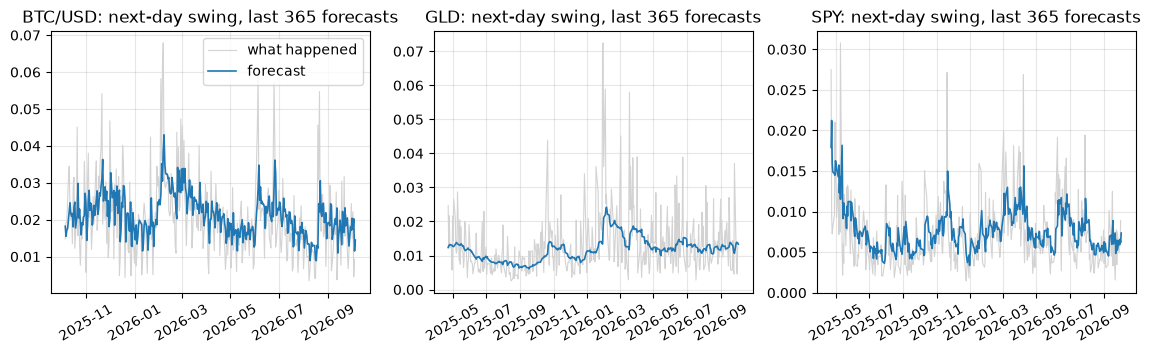

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))
for ax, s in zip(axes, symbols):
    part = forecasts[(forecasts["symbol"] == s) & (forecasts["horizon_days"] == 1) & (forecasts["model"] == "har")].sort_values("ts").iloc[-365:]
    ax.plot(part["ts"], part["realised"], color="lightgrey", linewidth=0.8, label="what happened")
    ax.plot(part["ts"], part["forecast"], color="tab:blue", linewidth=1.2, label="forecast")
    ax.set(title=f"{s}: next-day swing, last {len(part)} forecasts")
    ax.tick_params(axis="x", rotation=30)
axes[0].legend();

### Is it better than the alternatives?

Four methods are scored on the same unseen days with QLIKE, a standard loss for
volatility forecasts (0 is perfect; lower is better). The Diebold-Mariano test then
asks whether each method's difference from HAR could be chance: a p-value under 0.05
means the difference is real.

In [5]:
rows = []
for s in symbols:
    for horizon, evaluation in vol_metrics[s].items():
        for score in evaluation["scores"]:
            rows.append({"market": s, "horizon (days)": int(horizon), "unseen days": evaluation["n"],
                         "method": NAMES[score["model"]], "QLIKE": score["qlike"],
                         "p-value against HAR": score.get("dm_p_value_vs_har"),
                         "shown in the app": score["model"] == evaluation["shown"]})
scores = pd.DataFrame(rows).set_index(["market", "horizon (days)", "method"])
scores

unseen days  QLIKE  \
market  horizon (days) method                                   
BTC/USD 1              HAR regression             1601 0.4672   
                       Tree model                 1601 0.5657   
                       Yesterday repeated         1601 0.9237   
                       Regime average             1601 0.5352   
        7              HAR regression             1595 0.1940   
                       Tree model                 1595 0.2080   
                       Yesterday repeated         1595 1.3286   
                       Regime average             1595 0.2511   
GLD     1              HAR regression             2201 0.6672   
                       Tree model                 2201 0.8717   
                       Yesterday repeated         2201 1.8221   
                       Regime average             2201 0.6589   
        7              HAR regression             2197 0.2568   
                       Tree model                 2197 0.2979   
                       Yesterday repeated         2197 1.5220   
                       Regime average             2197 0.2961   
SPY     1              HAR regression             2201 0.4910   
                       Tree model                 2201 0.6735   
                       Yesterday repeated         2201 0.8710   
                       Regime average             2201 0.7593   
        7              HAR regression             2197 0.3346   
                       Tree model                 2197 0.4920   
                       Yesterday repeated         2197 0.9034   
                       Regime average             2197 0.5802   

                                           p-value against HAR  \
market  horizon (days) method                                    
BTC/USD 1              HAR regression                      NaN   
                       Tree model                       0.0000   
                       Yesterday repeated               0.0000   
                       Regime average                   0.0018   
        7              HAR regression                      NaN   
                       Tree model                       0.2544   
                       Yesterday repeated               0.0000   
                       Regime average                   0.0004   
GLD     1              HAR regression                      NaN   
                       Tree model                       0.0000   
                       Yesterday repeated               0.0000   
                       Regime average                   0.6472   
        7              HAR regression                      NaN   
                       Tree model                       0.0001   
                       Yesterday repeated               0.0000   
                       Regime average                   0.0126   
SPY     1              HAR regression                      NaN   
                       Tree model                       0.0000   
                       Yesterday repeated               0.0000   
                       Regime average                   0.0000   
        7              HAR regression                      NaN   
                       Tree model                       0.0020   
                       Yesterday repeated               0.0000   
                       Regime average                   0.0126   

                                           shown in the app  
market  horizon (days) method                                
BTC/USD 1              HAR regression                  True  
                       Tree model                     False  
                       Yesterday repeated             False  
                       Regime average                 False  
        7              HAR regression                  True  
                       Tree model                     False  
                       Yesterday repeated             False  
                       Regime average                 False  
GLD     1      

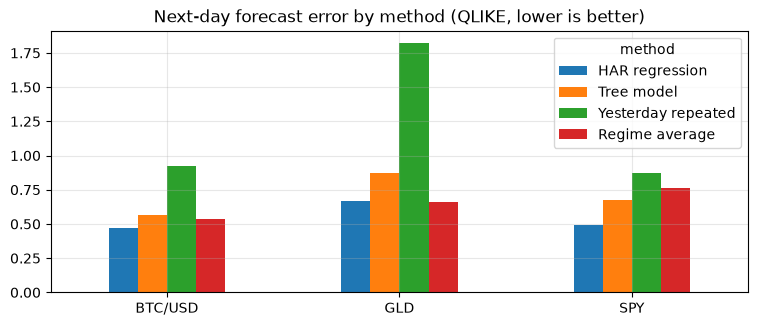

In [6]:
one_day = scores.xs(1, level="horizon (days)")["QLIKE"].unstack("method")[list(NAMES.values())]
ax = one_day.plot.bar(figsize=(9, 3.4), rot=0)
ax.set(title="Next-day forecast error by method (QLIKE, lower is better)", xlabel="");

**What this says.** HAR beats "yesterday repeated" by a wide margin everywhere. The
tree model, which also sees the regime probabilities, is never better than HAR on
unseen days, so the app shows HAR. The tree model does not yet have news tone as an
input; that comparison is repeated once it does.

## Part 2. Downside risk

- **Value at Risk (95%)**: the loss that should be exceeded in only 1 period in 20.
- **Expected shortfall**: the average loss in the periods that do exceed it.

Three ways to estimate them are compared:

- *historical*: take the worst outcomes of the last 500 periods as they were;
- *filtered*: scale those past outcomes to today's expected swings (from Part 1), so
  calm history counts for more in rough markets;
- *simulator*: read the limit off the outlook simulation.

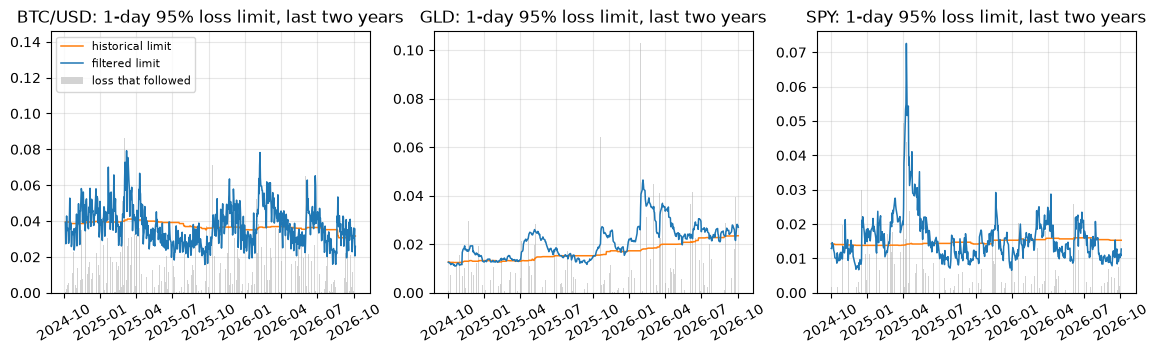

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))
for ax, s in zip(axes, symbols):
    part = risk[(risk["symbol"] == s) & (risk["horizon_days"] == 1) & (risk["level"] == 0.95)].sort_values("ts")
    recent = part[part["ts"] >= part["ts"].max() - pd.Timedelta(days=730)]
    filtered = recent[recent["method"] == "filtered"]
    ax.bar(filtered["ts"], filtered["realised_loss"].clip(lower=0), color="lightgrey", width=1, label="loss that followed")
    for method, colour in (("historical", "tab:orange"), ("filtered", "tab:blue")):
        line = recent[recent["method"] == method]
        ax.plot(line["ts"], line["var"], color=colour, linewidth=1.1, label=f"{method} limit")
    ax.set(title=f"{s}: 1-day 95% loss limit, last two years")
    ax.tick_params(axis="x", rotation=30)
axes[0].legend(fontsize=8);

The filtered limit (blue) moves with market conditions; the historical one (orange)
reacts slowly. A grey bar poking above a line is a **breach**: the loss was larger
than the limit said it should be.

### Counting breaches

A 95% limit should be broken about 5% of the time. Kupiec's test checks whether the
actual rate is close enough to that; a p-value under 0.05 marks the limit as
unreliable. A second test (clustering) checks whether breaches arrive in bunches.

In [8]:
rows = []
for s in symbols:
    for horizon, stored in risk_metrics[s]["horizons"].items():
        for b in stored["backtests"]:
            rows.append({"market": s, "horizon (days)": int(horizon), "method": b["method"], "level": b["level"],
                         "periods": b["n"], "breaches": b["breaches"], "expected": round(b["expected_breaches"], 1),
                         "Kupiec p": b["kupiec_p_value"], "clustering p": b["clustering_p_value"],
                         "reliable": b["reliable"], "shown": b["method"] == stored["shown"]})
backtests = pd.DataFrame(rows).set_index(["market", "horizon (days)", "level", "method"]).sort_index()
backtests

periods  breaches  expected  \
market  horizon (days) level  method                                    
BTC/USD 1              0.9500 filtered       1351        73   67.6000   
                              historical     1351        61   67.6000   
                              simulator      1351        58   67.6000   
                       0.9900 filtered       1351        12   13.5000   
                              historical     1351        10   13.5000   
                              simulator      1351        11   13.5000   
        7              0.9500 filtered        192        11    9.6000   
                              historical      192         7    9.6000   
                              simulator       192         6    9.6000   
                       0.9900 filtered        192         3    1.9000   
                              historical      192         1    1.9000   
                              simulator       192         2    1.9000   
GLD     1              0.9500 filtered       1951       106   97.6000   
                              historical     1951       130   97.6000   
                              simulator      1951       116   97.6000   
                       0.9900 filtered       1951        21   19.5000   
                              historical     1951        35   19.5000   
                              simulator      1951        31   19.5000   
        7              0.9500 filtered        389        26   19.5000   
                              historical      389        31   19.5000   
                              simulator       389        27   19.5000   
                       0.9900 filtered        389         7    3.9000   
                              historical      389        10    3.9000   
                              simulator       389        11    3.9000   
SPY     1              0.9500 filtered       1951        91   97.6000   
                              historical     1951        86   97.6000   
                              simulator      1951       115   97.6000   
                       0.9900 filtered       1951        22   19.5000   
                              historical     1951        27   19.5000   
                              simulator      1951        35   19.5000   
        7              0.9500 filtered        389        16   19.5000   
                              historical      389        17   19.5000   
                              simulator       389        22   19.5000   
                       0.9900 filtered        389         5    3.9000   
                              historical      389         7    3.9000   
                              simulator       389         7    3.9000   

                                          Kupiec p  clustering p  reliable  \
market  horizon (days) level  method                                         
BTC/USD 1              0.9500 filtered      0.5016        0.1383      True   
                              historical    0.4061        0.1993      True   
                              simulator     0.2223        0.0127      True   
                       0.9900 filtered      0.6738        0.6427      True   
                              historical    0.3144        0.6992      True   
                              simulator     0.4782        0.6707      True   
        7              0.9500 filtered      0.6502        0.1333      True   
                              historical    0.3667        0.2355      True   
                              simulator     0.2016        0.1619      True   
                       0.9900 filtered      0.4692        0.7570      True   
                              historical    0.4625        0.9183      True   
                              simulator     0.9540        0.8370      True   
GLD     1              0.9500 filtered      0.3864        0.1836      True   
                              historical    0.0013        0.1380     False   
                   

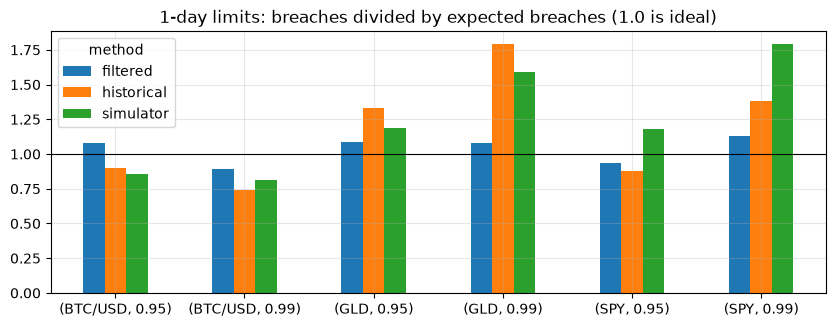

In [9]:
rate = backtests.assign(ratio=backtests["breaches"] / backtests["expected"]).xs(1, level="horizon (days)")["ratio"].unstack("method")
ax = rate.plot.bar(figsize=(10, 3.4), rot=0)
ax.axhline(1.0, color="black", linewidth=0.8)
ax.set(title="1-day limits: breaches divided by expected breaches (1.0 is ideal)", xlabel="");

Bars near 1.0 are limits that held as stated. Well above 1.0 means the limit was too
tight (broken too often); well below means too loose.

### The deepest falls on record

In [10]:
pd.concat({s: pd.DataFrame(risk_metrics[s]["drawdowns"]) for s in symbols}).droplevel(1)

,depth,peak_day,trough_day,recovered_day
BTC/USD,-0.7667,2021-11-08,2022-11-21,2024-03-04
BTC/USD,-0.5315,2021-04-13,2021-07-20,2021-10-19
BTC/USD,-0.5309,2025-10-06,2026-06-30,NaN
BTC/USD,-0.2815,2025-01-21,2025-04-08,2025-05-18
BTC/USD,-0.2618,2024-03-13,2024-09-06,2024-11-06
GLD,-0.2640,2026-01-29,2026-07-16,NaN
GLD,-0.2200,2020-08-06,2022-09-26,2024-03-04
GLD,-0.1774,2016-07-08,2016-12-15,2019-06-20
GLD,-0.1288,2020-03-09,2020-03-16,2020-04-09
GLD,-0.1013,2025-10-20,2025-11-04,2025-12-22


## What to take from this

- Swings are forecastable to a useful degree, and a three-number regression does it
  better than a more complex model here.
- Scaling past losses to expected swings gives the most reliable loss limits for most
  markets and horizons. The app shows whichever method had the best backtest and marks
  any limit that failed its test.
- The 7-day test uses periods that do not overlap, so it has few of them (about 190
  for Bitcoin). A 99% limit judged on that few periods is rough.